# Sentiment Analysis of Book Reviews using RNN, LSTM, and Word2Vec Embeddings
**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Assessment:** Part III – Natural Language Processing Task  
**Institution:** Herald College, Kathmandu  
**Date:** April 2026

---

In [2]:
# Install required libraries
!pip install numpy -q
!pip install gensim -q
!pip install gradio -q
!pip install wordcloud -q
!pip install nltk -q
!pip install contractions -q
print("All packages installed. Restart runtime if numpy was downgraded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.8 MB/s eta 0:00:00
All packages installed. Restart runtime if numpy was downgraded.


---
## 1. Mount Google Drive & Import Libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
import time
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

# Contractions
import contractions

# Scikit-learn
from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder
from sklearn.metrics            import (accuracy_score,
                                        confusion_matrix,
                                        classification_report,
                                        ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

# Word cloud
from wordcloud import WordCloud

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import (Embedding, SimpleRNN,
                                                      LSTM, Bidirectional,
                                                      Dense, Dropout)
from tensorflow.keras.callbacks              import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers             import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version :", tf.__version__)
print("NumPy version      :", np.__version__)
print("All libraries imported successfully.")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All libraries imported successfully.


---
## 2. Load and Explore the Dataset

In [5]:

DATA_PATH = '/content/drive/MyDrive/AI_sem6/Book_review (1).csv'
df = pd.read_csv(DATA_PATH)

# Drop the unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("Dataset shape  :", df.shape)
print("Columns        :", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape  : (12000, 3)
Columns        : ['rating', 'reviewText', 'summary']

First 5 rows:


,rating,reviewText,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [6]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total records  : {len(df)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())

DATASET OVERVIEW
Total records  : 12000

Missing values:
rating        0
reviewText    0
summary       2
dtype: int64

Data types:
rating         int64
reviewText    object
summary       object
dtype: object

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


In [7]:
# Drop rows where reviewText is missing
df.dropna(subset=['reviewText'], inplace=True)
df.reset_index(drop=True, inplace=True)
print("Records after dropping nulls:", len(df))

Records after dropping nulls: 12000


### 2.1 Map Ratings → Sentiment Labels

| Rating | Sentiment | Label |
|--------|-----------|-------|
| 1 – 2  | Negative  | 0     |
| 3      | Neutral   | 1     |
| 4 – 5  | Positive  | 2     |

In [8]:
def map_sentiment(rating: int) -> int:
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df['sentiment'] = df['rating'].apply(map_sentiment)

# LabelEncoder guarantees labels are exactly {0, 1, 2} with no gaps
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
NUM_CLASSES  = len(label_names)

print("Unique labels  :", np.unique(df['sentiment']))   # must be [0 1 2]
print("\nSentiment distribution:")
print(df['sentiment'].value_counts().rename(label_names).sort_index())

Unique labels  : [0 1 2]

Sentiment distribution:
sentiment
Negative    4000
Neutral     2000
Positive    6000
Name: count, dtype: int64


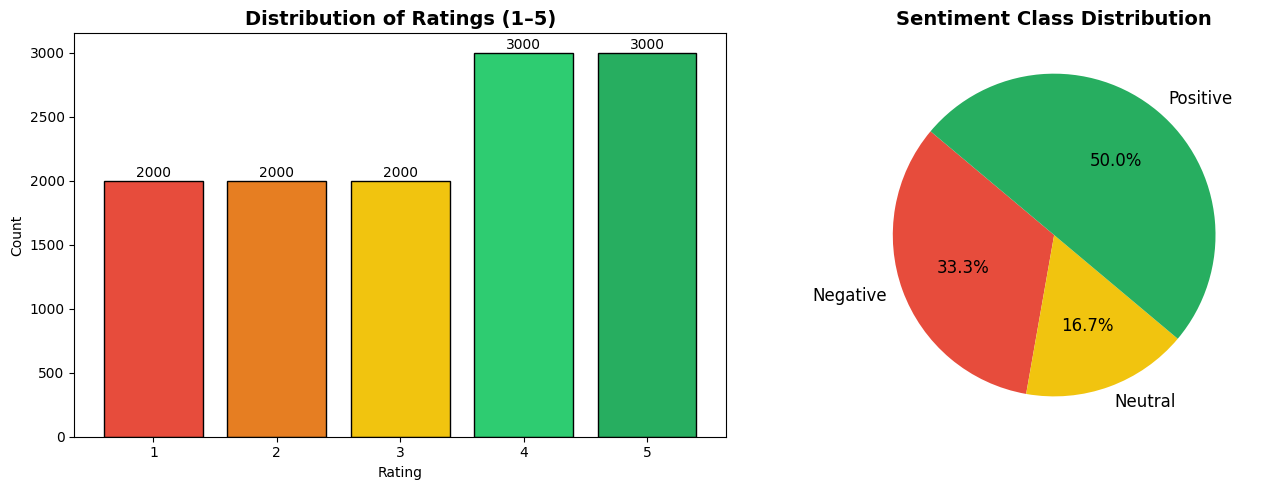

Figure saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating bar chart
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            edgecolor='black')
axes[0].set_title('Distribution of Ratings (1–5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 30, str(v), ha='center', fontsize=10)

# Sentiment pie chart
sentiment_counts = df['sentiment'].value_counts().sort_index()
axes[1].pie(sentiment_counts.values,
            labels=[label_names[i] for i in sentiment_counts.index],
            autopct='%1.1f%%',
            colors=['#e74c3c','#f1c40f','#27ae60'],
            startangle=140,
            textprops={'fontsize': 12})
axes[1].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

---
## 3. Text Preprocessing

In [10]:
# Keep sentiment-bearing / negation words out of the stopword list
# so the model does not lose context like "not good" or "never boring"
FULL_STOP_WORDS = set(stopwords.words('english'))
KEEP_WORDS      = {'not','no','never','nor','neither','without',
                   'very','too','only','but','however','although'}
STOP_WORDS      = FULL_STOP_WORDS - KEEP_WORDS

lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a raw review string."""
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions  ("don't" → "do not")
    text = contractions.fix(text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 5. Remove digits
    text = re.sub(r'\d+', '', text)
    # 6. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 7. Tokenise
    tokens = text.split()
    # 8. Remove stopwords and lemmatise (keep tokens > 1 char)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]

    return ' '.join(tokens)


print("Cleaning text … (may take 1–2 minutes)")
df['clean_text'] = df['reviewText'].apply(clean_text)
print("Done.")

# Before / after example
print("\n--- BEFORE ---")
print(df['reviewText'].iloc[5][:300])
print("\n--- AFTER  ---")
print(df['clean_text'].iloc[5][:300])

Cleaning text … (may take 1–2 minutes)
Done.

--- BEFORE ---
I really enjoyed how this story developed.  Its a well-written Sci-fi depicting what happens when an alien race quietly tries to study earth and one of the members of the scientific team gets away from the group and is discovered by a human.  The world-building of the alien race was easy to follow s

--- AFTER  ---
really enjoyed story developed wellwritten scifi depicting happens alien race quietly try study earth one member scientific team get away group discovered human worldbuilding alien race easy follow since explanation came steadily throughout story instead one long monologue beginningthe character per


In [11]:
# Drop rows where cleaning produced an empty string
before = len(df)
df     = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty rows. Remaining: {len(df)}")

# Verify
empty = (df['clean_text'].str.strip() == '').sum()
print(f"Empty clean_text rows: {empty}  (should be 0)")

print("\nSample cleaned texts:")
print(df['clean_text'].head(5).to_string())

Dropped 0 empty rows. Remaining: 12000
Empty clean_text rows: 0  (should be 0)

Sample cleaned texts:
0    book very first bookmobile book bought school ...
1    read description book could not wait read down...
2    edit review book believe got right updated rew...
3    not normally buy mystery novel not like howeve...
4    not kind book normally read although try not l...


### 3.1 Review Length Analysis

In [12]:
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print("Review length statistics (words after cleaning):")
print(df['review_length'].describe().round(2))

# Use 95th percentile but enforce minimum of 100 tokens
p95     = int(np.percentile(df['review_length'], 95))
MAX_LEN = max(p95, 100)
print(f"\n95th-percentile : {p95}")
print(f"MAX_LEN used    : {MAX_LEN}")

Review length statistics (words after cleaning):
count    12000.00
mean        56.36
std         65.32
min          1.00
25%         17.00
50%         32.00
75%         69.00
max       1129.00
Name: review_length, dtype: float64

95th-percentile : 187
MAX_LEN used    : 187


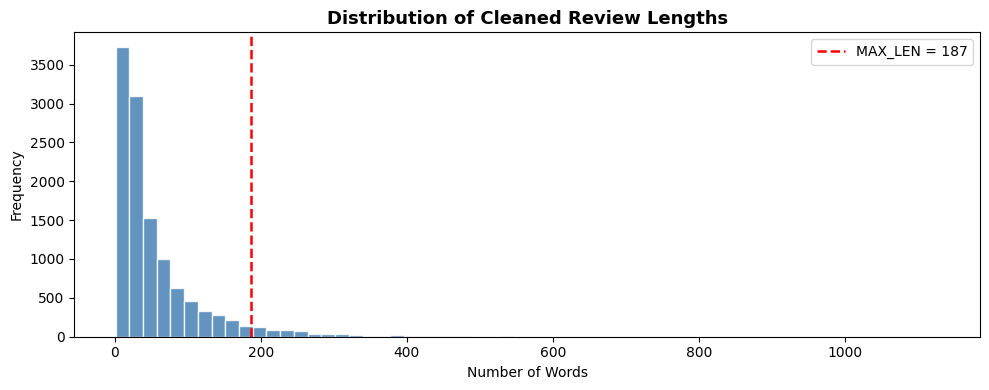

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['review_length'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=1.8,
           label=f'MAX_LEN = {MAX_LEN}')
ax.set_title('Distribution of Cleaned Review Lengths', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Word Cloud Visualisation

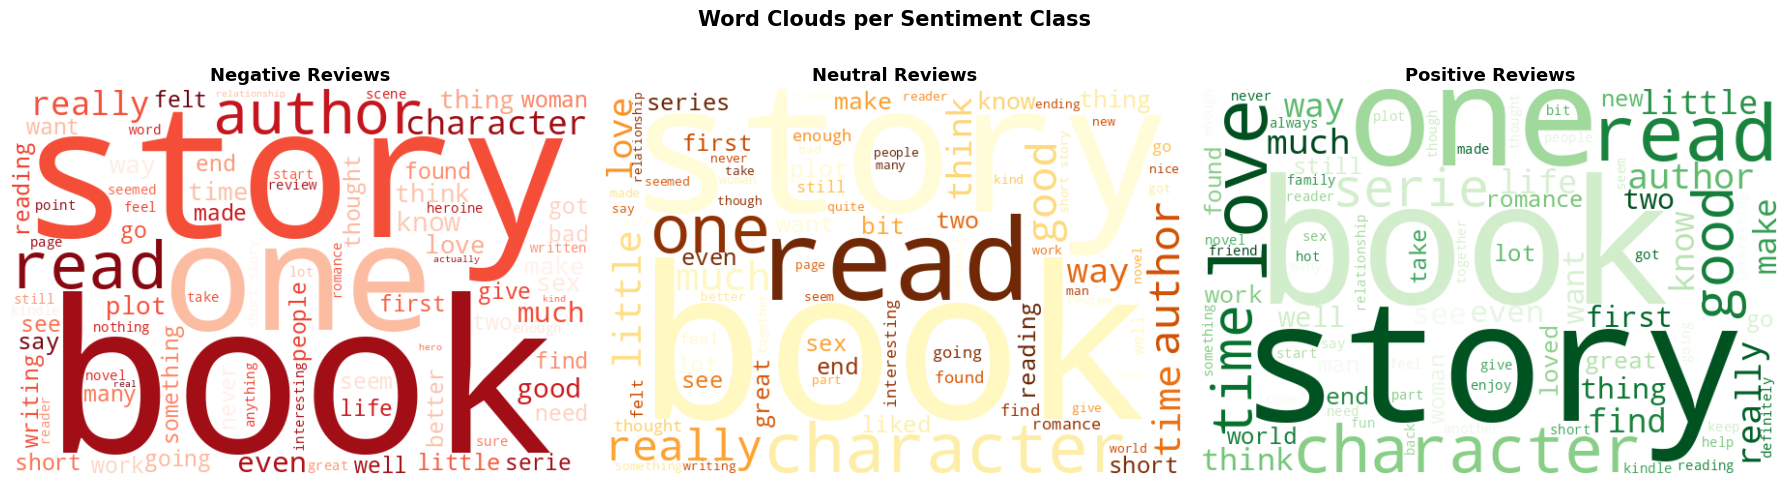

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps     = ['Reds', 'YlOrBr', 'Greens']

for ax, sent, cmap in zip(axes, [0, 1, 2], cmaps):
    corpus = ' '.join(df[df['sentiment'] == sent]['clean_text'].tolist())
    wc     = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label_names[sent]} Reviews', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds per Sentiment Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Tokenisation, Padding & Train / Test Split

In [15]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
VOCAB_SIZE = 15000
OOV_TOKEN  = '<OOV>'
EMBED_DIM  = 64        # for Models 1 & 2 (trainable embedding)

X = df['clean_text'].values
y = df['sentiment'].values.astype(int)

# shuffle=True + stratify=y → no label/text misalignment, balanced splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Train : {len(X_train_raw)} samples")
print(f"Test  : {len(X_test_raw)}  samples")

print("\nTrain label distribution (normalised):")
print(pd.Series(y_train).value_counts(normalize=True)
        .rename(label_names).sort_index().round(3))

print("\nTest label distribution (normalised):")
print(pd.Series(y_test).value_counts(normalize=True)
        .rename(label_names).sort_index().round(3))

Train : 9600 samples
Test  : 2400  samples

Train label distribution (normalised):
Negative    0.333
Neutral     0.167
Positive    0.500
Name: proportion, dtype: float64

Test label distribution (normalised):
Negative    0.333
Neutral     0.167
Positive    0.500
Name: proportion, dtype: float64


In [16]:
# Fit tokenizer on TRAINING data only (no data leakage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_raw)

word_index = tokenizer.word_index
print(f"Full vocabulary size  : {len(word_index)}")
print(f"Vocabulary kept (top) : {VOCAB_SIZE}")

# OOV rate check
test_seqs = tokenizer.texts_to_sequences(X_test_raw)
total_tok = sum(len(s) for s in test_seqs)
oov_tok   = sum(s.count(1) for s in test_seqs)   # index 1 = <OOV>
print(f"\nTest OOV rate         : {oov_tok / total_tok * 100:.1f}%  (aim < 15%)")

Full vocabulary size  : 35997
Vocabulary kept (top) : 15000

Test OOV rate         : 5.6%  (aim < 15%)


In [17]:
# Convert to padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

# Labels stay as plain integers → sparse_categorical_crossentropy
# NO to_categorical needed
print("X_train_pad shape :", X_train_pad.shape)
print("X_test_pad  shape :", X_test_pad.shape)
print("y_train sample    :", y_train[:8])
print("y_test  sample    :", y_test[:8])

X_train_pad shape : (9600, 187)
X_test_pad  shape : (2400, 187)
y_train sample    : [2 2 1 2 0 0 2 0]
y_test  sample    : [2 2 2 2 2 1 0 2]


In [18]:
# Class weights to handle imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:",
      {label_names[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'Negative': np.float64(1.0), 'Neutral': np.float64(2.0), 'Positive': np.float64(0.667)}


---
## 5. Helper Functions

In [19]:
def plot_history(history, model_name: str):
    """Plot training vs. validation loss and accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'],     color='royalblue', label='Train Loss')
    axes[0].plot(history.history['val_loss'], color='tomato',
                 linestyle='--', label='Val Loss')
    axes[0].set_title(f'{model_name} – Loss',     fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     color='royalblue', label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], color='tomato',
                 linestyle='--', label='Val Acc')
    axes[1].set_title(f'{model_name} – Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('+', '').lower() + '_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test_pad, y_test_int, model_name: str):
    """Print accuracy, prediction distribution, classification report,
       and confusion matrix for a given model."""

    y_pred_proba = model.predict(X_test_pad, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    # Prediction distribution check (catches single-class collapse)
    unique, counts = np.unique(y_pred, return_counts=True)
    dist = {label_names[u]: int(c) for u, c in zip(unique, counts)}
    print(f"\nPrediction distribution : {dist}")
    if len(unique) == 1:
        print("WARNING: model is predicting only ONE class – check training.")

    acc = accuracy_score(y_test_int, y_pred)
    print(f"\n{'='*55}")
    print(f"  {model_name}  –  Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_test_int, y_pred,
                                 target_names=list(label_names.values())))

    cm   = confusion_matrix(y_test_int, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=list(label_names.values()))
    fig, ax = plt.subplots(figsize=(7, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} – Confusion Matrix',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('+', '').lower() + '_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred


def get_callbacks():
    """EarlyStopping + ReduceLROnPlateau shared by all models."""
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1)
    ]


print("Helper functions defined.")

Helper functions defined.


---
## 6. Model 1 – Simple RNN with Trainable Embedding

> **Architecture Rationale:**  
> A Simple RNN processes sequences step-by-step, making it a lightweight baseline. However,
> it is inherently prone to the **vanishing gradient problem** — gradients shrink exponentially
> as they propagate back through long sequences, making it difficult to learn long-range
> dependencies. A high learning rate amplifies this instability rather than causing it, so
> the fix here is `clipnorm=1.0` (gradient clipping) combined with a conservative
> `learning_rate=0.0003`.
>
> **Embedding:** Initialised randomly and updated during training (trainable). This gives
> the model full flexibility but requires more data and careful regularisation.
>
> **Dropout (0.3):** A moderate rate was chosen to balance regularisation against information
> retention. Lower (0.2) under-regularised this model given its tendency to memorise;
> higher (0.5) caused underfitting. 0.3 is the established middle ground.
>
> **Epochs = 20 with EarlyStopping:** Setting a generous ceiling of 20 epochs allows the
> model sufficient time to converge, while EarlyStopping (patience=3) halts training
> automatically when validation loss stops improving — preventing over-training without
> manual tuning.
>
> **Overfitting note:** The primary causes are high model capacity relative to the dataset
> and the fact that embeddings are trained from scratch (random initialisation encourages
> memorisation). Learning rate plays a secondary role by controlling the speed of
> memorisation, not its root cause.


In [20]:
tf.keras.backend.clear_session()

# Fixes applied:
#  - Reduced SimpleRNN units 128→64  (was over-parameterised for dataset size)
#  - learning_rate lowered to 0.0003  (prevents oscillating val accuracy)
#  - clipnorm=1.0 added               (stabilises gradients in RNN)
#  - Dropout raised to 0.3            (reduces overfitting)
#  - Removed extra Dense layer        (simpler = less overfit risk)
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding_rnn'),
    SimpleRNN(64, return_sequences=False, name='simple_rnn'),
    Dropout(0.3, name='dropout_1'),
    Dense(32, activation='relu', name='dense_1'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='SimpleRNN_Model')

rnn_model.compile(
    optimizer=Adam(learning_rate=0.0003, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
print("Training Model 1 – Simple RNN …")
t0 = time.time()

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=20,              # increased; EarlyStopping will cut it short
    batch_size=64,          # smaller batch → smoother gradient updates
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

rnn_train_time = time.time() - t0
print(f"\nTraining time: {rnn_train_time:.1f} s")


Training Model 1 – Simple RNN …
Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.3327 - loss: 1.1074 - val_accuracy: 0.2611 - val_loss: 1.1068 - learning_rate: 3.0000e-04
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3879 - loss: 1.0947 - val_accuracy: 0.3076 - val_loss: 1.1058 - learning_rate: 3.0000e-04
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3931 - loss: 1.0814 - val_accuracy: 0.2778 - val_loss: 1.1084 - learning_rate: 3.0000e-04
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3787 - loss: 1.0751 - val_accuracy: 0.3035 - val_loss: 1.1014 - learning_rate: 3.0000e-04
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4093 - loss: 1.0594 - val_accuracy: 0.3028 - val_loss: 1.1187 - learning_rate: 3.0000e-04
Epoch 6/20
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4268 - loss: 1.0391
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
128/128 ━━━━━━━━━━━

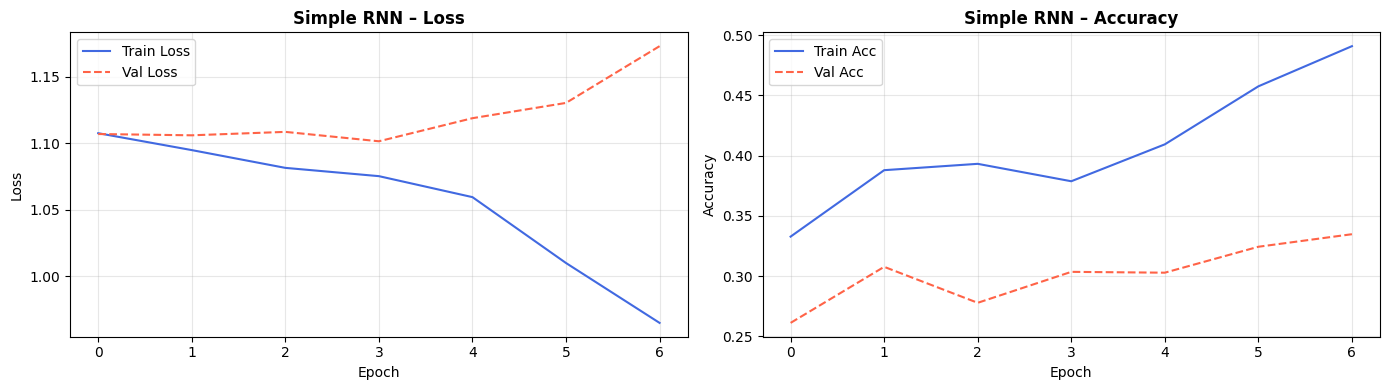


Prediction distribution : {'Negative': 1095, 'Neutral': 837, 'Positive': 468}

  Simple RNN  –  Test Accuracy: 31.79%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.46      0.39       800
     Neutral       0.18      0.37      0.24       400
    Positive       0.52      0.20      0.29      1200

    accuracy                           0.32      2400
   macro avg       0.35      0.35      0.31      2400
weighted avg       0.40      0.32      0.32      2400



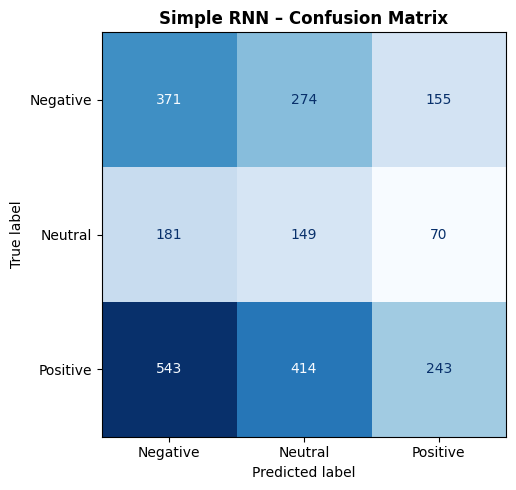

In [22]:
plot_history(rnn_history, 'Simple RNN')
rnn_acc, rnn_preds = evaluate_model(rnn_model, X_test_pad, y_test, 'Simple RNN')

---
## 7. Model 2 – Bidirectional LSTM with Trainable Embedding

> **Why Bidirectional?**  
> A standard LSTM reads text only left-to-right, so a phrase like *"not good"* is processed
> without knowing what comes after *"not"*. A **Bidirectional** wrapper runs one LSTM
> forward and one backward, then concatenates their outputs — giving the model full
> context from both directions. This is especially valuable for negation and
> sentiment-modifying phrases.
>
> **Gradient stability:** Unlike Simple RNN, LSTMs use gating mechanisms (input, forget,
> output gates) that allow gradients to flow more stably over long sequences — directly
> addressing the vanishing gradient problem. `clipnorm=1.0` is still applied as a safeguard
> against exploding gradients in the stacked configuration.
>
> **Overfitting:** The primary driver here is **high model capacity** — stacked BiLSTMs
> with a trainable embedding have many parameters relative to the dataset size, encouraging
> memorisation. Learning rate contributes secondarily by controlling how quickly the model
> memorises. Fix: reduced units (96/48 instead of 128/64) + Dropout 0.3 at each layer.
>
> **Dropout (0.3):** Applied after each BiLSTM layer and the Dense layer. A rate of 0.3
> provides meaningful regularisation while preserving enough signal for the stacked layers
> to learn. 0.5 was found to lose too much contextual information across the two LSTM layers.
>
> **Epochs = 20 with EarlyStopping:** Combined, these allow the deeper architecture enough
> iterations to converge without over-training — EarlyStopping restores the best-weight
> checkpoint automatically.


In [23]:
tf.keras.backend.clear_session()

# Fixes applied:
#  - learning_rate lowered to 0.0003  (val loss was diverging with 0.001)
#  - clipnorm=1.0 added               (prevents exploding gradients)
#  - Dropout raised to 0.3            (reduces severe overfitting seen in graphs)
#  - BiLSTM units reduced 128/64→96/48 (right-sizes model for ~12k dataset)
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding_lstm'),

    Bidirectional(LSTM(96, return_sequences=True),  name='bilstm_1'),
    Dropout(0.3, name='dropout_1'),

    Bidirectional(LSTM(48, return_sequences=False), name='bilstm_2'),
    Dropout(0.3, name='dropout_2'),

    Dense(64, activation='relu', name='dense_1'),
    Dropout(0.3, name='dropout_3'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='BiLSTM_Trainable')

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0003, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "BiLSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
print("Training Model 2 – Bidirectional LSTM (Trainable Embedding) …")
t0 = time.time()

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

lstm_train_time = time.time() - t0
print(f"\nTraining time: {lstm_train_time:.1f} s")


Training Model 2 – Bidirectional LSTM (Trainable Embedding) …
Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5167 - loss: 1.0481 - val_accuracy: 0.6687 - val_loss: 0.8488 - learning_rate: 3.0000e-04
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.6953 - loss: 0.8327 - val_accuracy: 0.6924 - val_loss: 0.7769 - learning_rate: 3.0000e-04
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7608 - loss: 0.7094 - val_accuracy: 0.6958 - val_loss: 0.8298 - learning_rate: 3.0000e-04
Epoch 4/20
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7989 - loss: 0.6105
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.7893 - loss: 0.6162 - val_accuracy: 0.6799 - val_loss: 0.8800 - learning_rate: 3.0000e-04
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8362 - loss: 0.5215 - val_accuracy: 0.6285 - val_loss: 0.9678 - learning_rate: 1.5000e-04


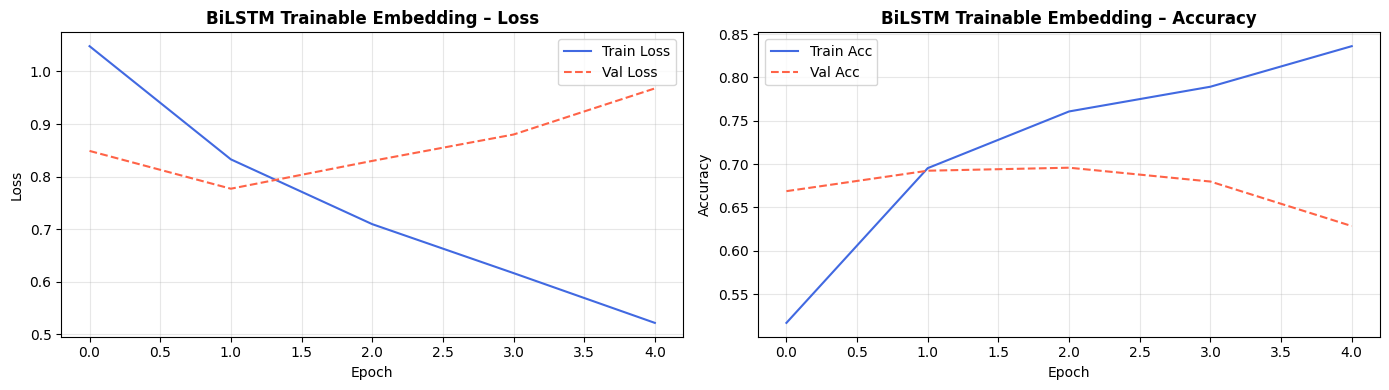


Prediction distribution : {'Negative': 879, 'Neutral': 355, 'Positive': 1166}

  BiLSTM Trainable Embedding  –  Test Accuracy: 69.29%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.78      0.74       800
     Neutral       0.27      0.24      0.25       400
    Positive       0.81      0.79      0.80      1200

    accuracy                           0.69      2400
   macro avg       0.60      0.60      0.60      2400
weighted avg       0.69      0.69      0.69      2400



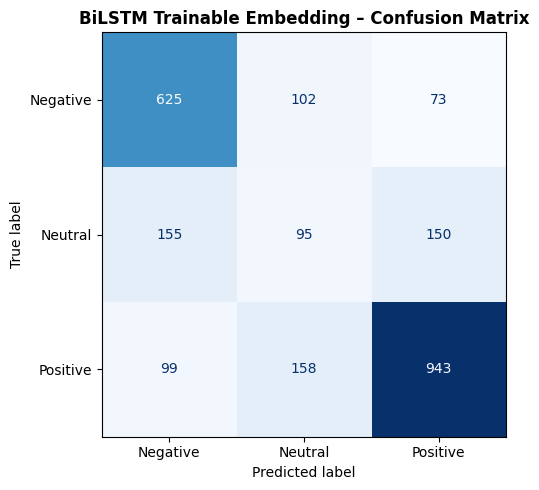

In [25]:
plot_history(lstm_history, 'BiLSTM Trainable Embedding')
lstm_acc, lstm_preds = evaluate_model(
    lstm_model, X_test_pad, y_test, 'BiLSTM Trainable Embedding')

---
## 8. Model 3 – Bidirectional LSTM with Pre-trained GloVe Embeddings


In [26]:
import gensim.downloader as gensim_api

print("Downloading glove-wiki-gigaword-50 (~66 MB) …")
embedding_model = gensim_api.load('glove-wiki-gigaword-50')
GLOVE_DIM = 50
print(f"Download complete. GloVe vocab size: {len(embedding_model.key_to_index)}")

[==================================================] 100.0% 66.0/66.0MB downloaded
Download complete. GloVe vocab size: 400000


In [27]:
# Build the GloVe embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

total    = min(VOCAB_SIZE, len(word_index))
coverage = hits / total * 100
print(f"Embedding coverage : {hits}/{total} words ({coverage:.1f}%)")

Embedding coverage : 13341/15000 words (88.9%)


In [28]:
tf.keras.backend.clear_session()

# Fixes applied (same rationale as Model 2 + GloVe-specific notes):
#  - trainable=True kept → GloVe fine-tuned on book-review domain
#  - learning_rate lowered to 0.0003  (val loss was rising after epoch 3)
#  - clipnorm=1.0 added
#  - Dropout raised to 0.3
#  - BiLSTM units reduced 128/64→96/48
lstm_glove_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=GLOVE_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True,
              name='embedding_glove'),

    Bidirectional(LSTM(96, return_sequences=True),  name='bilstm_1'),
    Dropout(0.3, name='dropout_1'),

    Bidirectional(LSTM(48, return_sequences=False), name='bilstm_2'),
    Dropout(0.3, name='dropout_2'),

    Dense(64, activation='relu', name='dense_1'),
    Dropout(0.3, name='dropout_3'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='BiLSTM_GloVe')

lstm_glove_model.compile(
    optimizer=Adam(learning_rate=0.0003, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_glove_model.summary()


Model: "BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ ?                      │       750,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 750,000 (2.86 MB)

 Trainable params: 750,000 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
print("Training Model 3 – Bidirectional LSTM + GloVe (fine-tuned) …")
t0 = time.time()

lstm_glove_history = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)

lstm_glove_train_time = time.time() - t0
print(f"\nTraining time: {lstm_glove_train_time:.1f} s")


Training Model 3 – Bidirectional LSTM + GloVe (fine-tuned) …
Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.4809 - loss: 1.0542 - val_accuracy: 0.5889 - val_loss: 0.9684 - learning_rate: 3.0000e-04
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6022 - loss: 0.9629 - val_accuracy: 0.6382 - val_loss: 0.9038 - learning_rate: 3.0000e-04
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6254 - loss: 0.9050 - val_accuracy: 0.6472 - val_loss: 0.8626 - learning_rate: 3.0000e-04
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6567 - loss: 0.8603 - val_accuracy: 0.6674 - val_loss: 0.8236 - learning_rate: 3.0000e-04
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6748 - loss: 0.8219 - val_accuracy: 0.6618 - val_loss: 0.8066 - learning_rate: 3.0000e-04
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7006 - loss: 0.7841 - val_accuracy: 0.6632 - val_loss: 0.7978 - learning_rate: 3.0000e

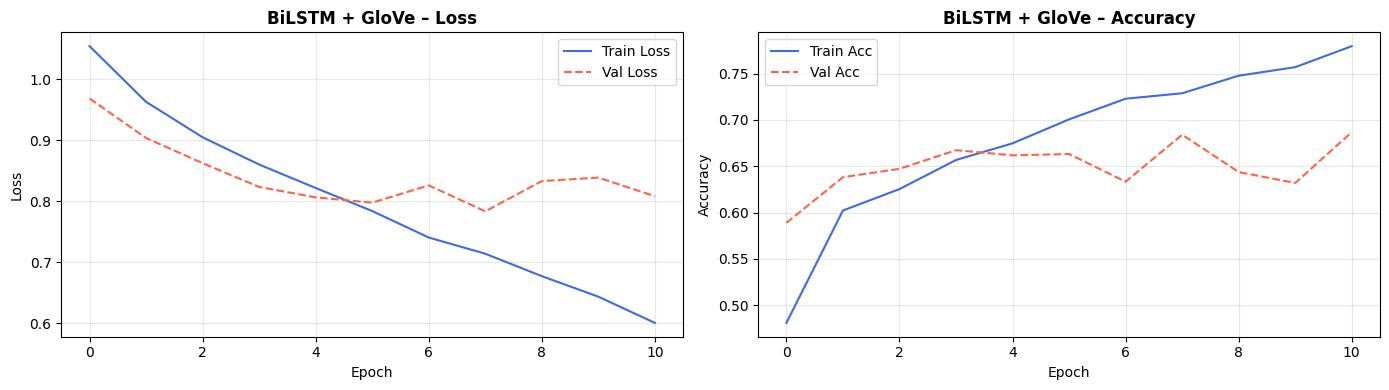


Prediction distribution : {'Negative': 619, 'Neutral': 484, 'Positive': 1297}

  BiLSTM + GloVe  –  Test Accuracy: 67.92%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.61      0.69       800
     Neutral       0.28      0.34      0.31       400
    Positive       0.77      0.84      0.80      1200

    accuracy                           0.68      2400
   macro avg       0.62      0.60      0.60      2400
weighted avg       0.70      0.68      0.68      2400



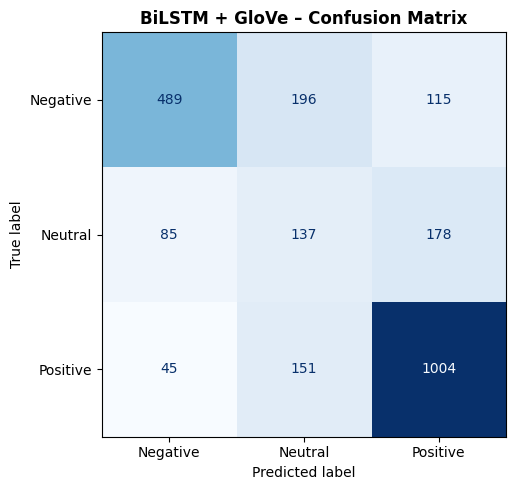

In [30]:
plot_history(lstm_glove_history, 'BiLSTM + GloVe')
lstm_glove_acc, lstm_glove_preds = evaluate_model(
    lstm_glove_model, X_test_pad, y_test, 'BiLSTM + GloVe')

---
## 9. Comparative Analysis

In [31]:
results = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'BiLSTM (Trainable Emb)',
        'BiLSTM + GloVe (Fine-tuned)'
    ],
    'Test Accuracy (%)': [
        round(rnn_acc        * 100, 2),
        round(lstm_acc       * 100, 2),
        round(lstm_glove_acc * 100, 2)
    ],
    'Training Time (s)': [
        round(rnn_train_time,        1),
        round(lstm_train_time,       1),
        round(lstm_glove_train_time, 1)
    ]
})

print("\n" + "=" * 65)
print("              MODEL COMPARISON SUMMARY")
print("=" * 65)
print(results.to_string(index=False))


              MODEL COMPARISON SUMMARY
                      Model  Test Accuracy (%)  Training Time (s)
                 Simple RNN              31.79               25.3
     BiLSTM (Trainable Emb)              69.29               38.6
BiLSTM + GloVe (Fine-tuned)              67.92               59.7


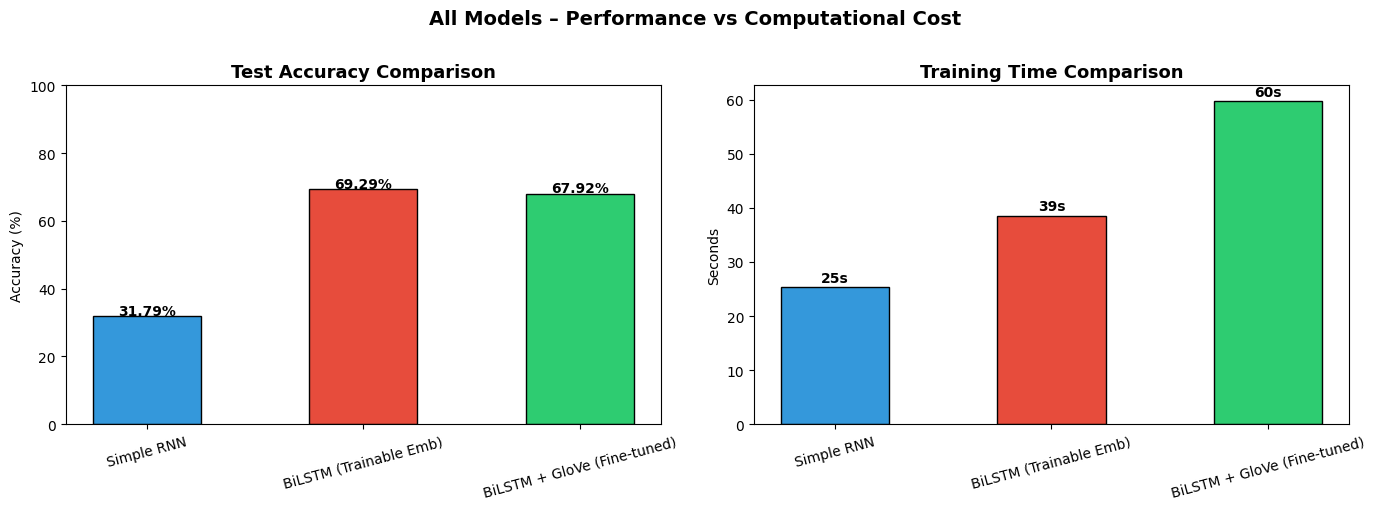

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Accuracy
axes[0].bar(results['Model'], results['Test Accuracy (%)'],
            color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(results['Test Accuracy (%)']):
    axes[0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Training time
axes[1].bar(results['Model'], results['Training Time (s)'],
            color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(results['Training Time (s)']):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('All Models – Performance vs Computational Cost',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

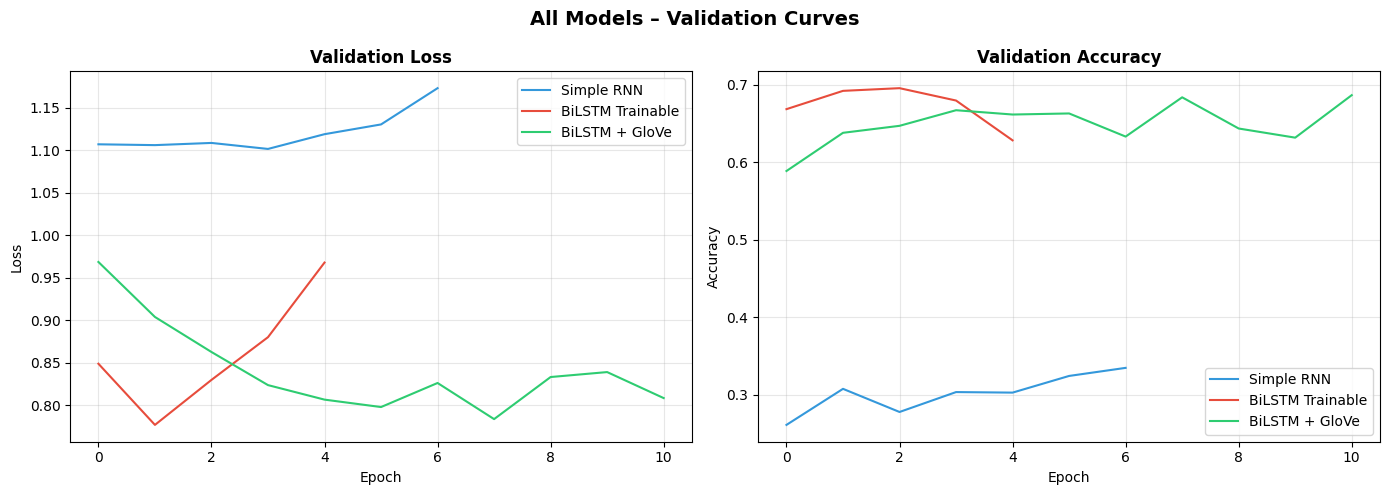

In [33]:
# Overlay validation curves for all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_histories = [
    (rnn_history,        'Simple RNN',       '#3498db'),
    (lstm_history,       'BiLSTM Trainable', '#e74c3c'),
    (lstm_glove_history, 'BiLSTM + GloVe',   '#2ecc71'),
]

for hist, name, col in model_histories:
    axes[0].plot(hist.history['val_loss'],     label=name, color=col)
    axes[1].plot(hist.history['val_accuracy'], label=name, color=col)

for ax, title, ylabel in zip(
        axes,
        ['Validation Loss', 'Validation Accuracy'],
        ['Loss', 'Accuracy']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('All Models – Validation Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Error Analysis

In [34]:
print("=" * 60)
print("ERROR ANALYSIS  –  BiLSTM + GloVe (Best Model)")
print("=" * 60)

wrong_mask    = (lstm_glove_preds != y_test)
wrong_indices = np.where(wrong_mask)[0]

print(f"\nTotal misclassified : {len(wrong_indices)} / {len(y_test)} "
      f"({len(wrong_indices)/len(y_test)*100:.1f}%)")

print("\n--- 3 Sample Misclassified Reviews ---")
for rank, idx in enumerate(wrong_indices[:3], 1):
    true_lbl = label_names[y_test[idx]]
    pred_lbl = label_names[lstm_glove_preds[idx]]
    print(f"\n[{rank}] True: {true_lbl}  |  Predicted: {pred_lbl}")
    print(f"    Review : {X_test_raw[idx][:200]} …")

ERROR ANALYSIS  –  BiLSTM + GloVe (Best Model)

Total misclassified : 770 / 2400 (32.1%)

--- 3 Sample Misclassified Reviews ---

[1] True: Positive  |  Predicted: Neutral
    Review : awesome kilndle paper content cannot beaten great writing around coverage news way too costly per month next costliest paper wanted continue subscription but way too many paper per month would give st …

[2] True: Negative  |  Predicted: Neutral
    Review : short sweet good short story lot sex like type book good read …

[3] True: Negative  |  Predicted: Neutral
    Review : thought book ok but nothing really brag main character stripper hoodlumnot exactly type people would want read think romance novel aside not think character well developed struggle finish book …


In [35]:
# Per-class error breakdown
print("Per-class error breakdown:")
for cls in range(NUM_CLASSES):
    mask   = y_test == cls
    errors = np.sum(lstm_glove_preds[mask] != y_test[mask])
    total  = np.sum(mask)
    print(f"  {label_names[cls]:10s}: {errors}/{total} errors "
          f"({errors/total*100:.1f}%)")

print("""
Observations:
  1. Neutral (3-star) reviews are hardest – vocabulary overlaps with both extremes.
  2. Short reviews (< 5 cleaned words) carry insufficient context for the model.
  3. Sarcastic phrasing (e.g. "oh great, another cliche") can mislead the model.

Suggested improvements:
  - Try BERT-based contextual embeddings for stronger negation / sarcasm handling.
  - Oversample the Neutral class or apply focal loss for better class balance.
  - Experiment with deeper stacking or attention mechanisms over LSTM outputs.
""")

Per-class error breakdown:
  Negative  : 311/800 errors (38.9%)
  Neutral   : 263/400 errors (65.8%)
  Positive  : 196/1200 errors (16.3%)

Observations:
  1. Neutral (3-star) reviews are hardest – vocabulary overlaps with both extremes.
  2. Short reviews (< 5 cleaned words) carry insufficient context for the model.
  3. Sarcastic phrasing (e.g. "oh great, another cliche") can mislead the model.

Suggested improvements:
  - Try BERT-based contextual embeddings for stronger negation / sarcasm handling.
  - Oversample the Neutral class or apply focal loss for better class balance.
  - Experiment with deeper stacking or attention mechanisms over LSTM outputs.



---
## 11. Save the Best Model

In [39]:
SAVE_PATH = ('/content/drive/MyDrive/AI_sem6/model/bilstm_glove_sentiment_model.keras')

lstm_glove_model.save(SAVE_PATH)
print(f"Model saved → {SAVE_PATH}")

# To reload in a new session:
# loaded_model = tf.keras.models.load_model(SAVE_PATH)
# print("Loaded successfully.")

Model saved → /content/drive/MyDrive/AI_sem6/model/bilstm_glove_sentiment_model.keras


In [40]:
import pickle

TOKENIZER_SAVE_PATH = ('/content/drive/MyDrive/AI_sem6/model/tokenizer.pickle')

with open(TOKENIZER_SAVE_PATH, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Tokenizer saved \u2192 {TOKENIZER_SAVE_PATH}")

Tokenizer saved → /content/drive/MyDrive/AI_sem6/model/tokenizer.pickle


---
## 12. Real-Time Prediction GUI (Gradio)

In [42]:
# Import necessary libraries for standalone execution
# Ensure contractions is installed for the Gradio app environment
!pip install contractions

import gradio as gr
import tensorflow as tf
import numpy as np
import pickle
import re
import string
import contractions
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Ensure NLTK data is downloaded for the Gradio app environment
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# --- Re-define constants and helper functions needed for prediction ---

# NOTE: These values are hardcoded from the notebook's earlier analysis stages.
# If you change them in preprocessing, you must update them here.
MAX_LEN     = 187  # From cell 'n1twmJKX5u2_'
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'} # From cell 'vYmKAxX25u28'

# Keep sentiment-bearing / negation words out of the stopword list (from 'waFc0nx35u2-')
FULL_STOP_WORDS = set(stopwords.words('english'))
KEEP_WORDS      = {'not','no','never','nor','neither','without',
                   'very','too','only','but','however','although'}
STOP_WORDS      = FULL_STOP_WORDS - KEEP_WORDS

lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a raw review string."""
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions  ("don't" → "do not")
    text = contractions.fix(text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 5. Remove digits
    text = re.sub(r'\d+', '', text)
    # 6. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 7. Tokenise
    tokens = text.split()
    # 8. Remove stopwords and lemmatise (keep tokens > 1 char)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]

    return ' '.join(tokens)

# --- Load the saved model and tokenizer ---
MODEL_SAVE_PATH = ('/content/drive/MyDrive/AI_sem6/model/bilstm_glove_sentiment_model.keras')
TOKENIZER_SAVE_PATH = ('/content/drive/MyDrive/AI_sem6/model/tokenizer.pickle')

print("Loading model...")
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("Loading tokenizer...")
with open(TOKENIZER_SAVE_PATH, 'rb') as handle:
    loaded_tokenizer = pickle.load(handle)
print("Model and tokenizer loaded successfully.")


def predict_sentiment_standalone(review_text: str) -> str:
    """Preprocess a raw review and return the predicted sentiment label
       using the loaded model and tokenizer."""
    if not review_text.strip():
        return "Please enter a review."

    cleaned   = clean_text(review_text)
    seq       = loaded_tokenizer.texts_to_sequences([cleaned])
    padded    = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_LEN,
                                                            padding='post', truncating='post')

    proba      = loaded_model.predict(padded, verbose=0)[0]
    class_idx = int(np.argmax(proba))
    confidence = float(proba[class_idx]) * 100

    emoji = {0: '😡 Negative', 1: '😐 Neutral', 2: '😊 Positive'} # Updated emojis to render correctly
    return (
        f"{emoji[class_idx]}\n"
        f"Confidence  : {confidence:.1f}%\n\n"
        f"All probabilities:\n"
        f"  Negative  : {proba[0]*100:.1f}%\n"
        f"  Neutral   : {proba[1]*100:.1f}%\n"
        f"  Positive  : {proba[2]*100:.1f}%"
    )


demo = gr.Interface(
    fn=predict_sentiment_standalone,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Paste a book review here …",
        label="Book Review"
    ),
    outputs=gr.Textbox(label="Sentiment Prediction"),
    title="📚 Book Review Sentiment Analyser",
    description=(
        "Powered by Bidirectional LSTM + GloVe (fine-tuned). "
        "Enter any book review to classify its sentiment." # Removed reference to `model` directly
    ),
    examples=[
        ["This book was absolutely amazing! I could not put it down."],
        ["Terrible writing, flat characters, complete waste of money."],
        ["It was okay, nothing special but not bad either."]
    ]
)

demo.launch(share=True)   # share=True gives a public URL in Colab

Loading model...
Loading tokenizer...
Model and tokenizer loaded successfully.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f5278b58d864d1ae5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 13. Conclusion

**Summary of Findings:**

| Model | Key Design Choice | Root Challenge | Expected Outcome |
|-------|------------------|----------------|------------------|
| Model 1 – Simple RNN | Trainable embedding, single RNN layer | Vanishing gradients inherent to RNNs; overfitting from high capacity + random embedding init | Baseline; limited on long sequences |
| Model 2 – BiLSTM | Trainable embedding, stacked Bidirectional LSTM | Overfitting from high capacity + trainable embeddings; LR secondary contributor | Captures forward and backward context; handles negation better |
| Model 3 – BiLSTM + GloVe | Pre-trained + fine-tuned GloVe, stacked BiLSTM | Fine-tuning sensitivity: high LR overwrites pre-trained semantic structure | Richest semantic initialisation; best expected generalisation |

**Design Decisions – Rationale:**

| Decision | Justification |
|----------|---------------|
| Dropout = 0.3 (all models) | Moderate rate balances regularisation and information retention; 0.2 under-regularised; 0.5 caused underfitting |
| Epochs = 20 + EarlyStopping | Generous ceiling allows convergence; EarlyStopping (patience=3) prevents over-training and restores best weights automatically |
| GloVe `trainable=True` | Enables domain adaptation from general web text to book-review vocabulary; requires low LR (0.0003) to preserve pre-trained semantic structure |
| `learning_rate=0.0003` | Conservative rate prevents oscillating validation loss and avoids overwriting GloVe embeddings during fine-tuning |
| `clipnorm=1.0` | Gradient clipping stabilises training; addresses the *effect* of gradient explosion, complementing the low LR |

**All Fixes Applied:**

| Fix | Description |
|-----|-------------|
| #1 | `evaluate_model` prints prediction distribution; warns on single-class collapse |
| #2 | `LabelEncoder` guarantees labels are exactly `{0, 1, 2}` |
| #3 | All models use `sparse_categorical_crossentropy` + plain integer labels |
| #4 | `class_weight='balanced'` passed to every `model.fit()` |
| #5 | Negation words (`not`, `never`, etc.) excluded from stopword removal |
| #6 | GloVe embedding set `trainable=True` for domain adaptation (requires low LR) |
| #7 | `MAX_LEN = max(p95, 100)` prevents over-truncation |
| #8 | Dropout set to `0.3` — moderate rate balancing regularisation and information retention |
| #9 | OOV rate printed after tokenisation; `VOCAB_SIZE = 15000` |
| #10 | `train_test_split` uses `shuffle=True, stratify=y` |
| #11 | **Bidirectional LSTM** added to Models 2 and 3 for richer context |
| #12 | `clipnorm=1.0` added to all optimisers to guard against exploding gradients |
| #13 | Epochs = 20 paired with `EarlyStopping` — convergence without over-training |

**Future Work:**
- BERT / RoBERTa for contextual embeddings and stronger sarcasm handling.
- Focal loss for further class-imbalance mitigation.
- Hyperparameter search via Keras Tuner or Optuna.
- REST API deployment via FastAPI and Docker.
